# G4b: TSTR Experiments (underperformance task)

**Authors:** Ivo Rambaldi & Tommaso Petrelli

**Course:** Ethics in Artificial Intelligence, University of Bologna, a.y. 2025-2026

---

## Overview

Same setup as G4, re-targeted at the symmetric lower-tail task (`target_low_perf`, score in the bottom 25%) following Marrero et al. (2024). Only the target column and the output directory change (config cell below); SMOTE is swapped for its low-perf-balanced variant, while the other three methods are shared with G4 since they never condition on the target. TSTR protocol, grid, metrics and figures are otherwise identical to G4.

Outputs go to `results/experiments/low_perf/` and `results/figures/low_perf/`.

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Put the project root on sys.path so 'src' imports resolve.
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.logging import get_logger

logger = get_logger('notebook_04')

logger.info(f"Environment ready. Project root: {PROJECT_ROOT}")

2026-07-19 15:01:25 | INFO     | notebook_04 | Environment ready. Project root: D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526


In [2]:
from src.utils.config import load_config
from src.data.persistence import ensure_dir

cfg = load_config(PROJECT_ROOT / 'config' / 'config.yaml')

# Re-target the underperformance task and route outputs to a sub-directory so
# this run never overwrites G4's target_high_perf results.
cfg['dataset']['target_column'] = cfg['target']['low_column_name']
cfg['paths']['experiments_dir'] = cfg['paths']['experiments_dir'] / 'low_perf'
cfg['paths']['figures_dir']     = cfg['paths']['figures_dir'] / 'low_perf'

EXPERIMENTS_DIR = Path(cfg["paths"]["experiments_dir"])
FIGURES_DIR     = Path(cfg["paths"]["figures_dir"])
ensure_dir(EXPERIMENTS_DIR)
ensure_dir(FIGURES_DIR)

methods     = cfg["generation"]["methods"]
classifiers = [k for k, v in cfg["experiments"]["classifiers"].items() if v.get("enabled", True)]
protected   = cfg["dataset"]["protected_attributes"]

print('=== Configuration summary ===')
print(f"Seed                : {cfg['seed']}")
print(f"Generation methods  : {methods}")
print(f"Classifiers         : {classifiers}")
print(f"Protected attributes: {len(protected)}")
print(f"Total experiments   : {(len(methods) + 1) * len(classifiers)}")

=== Configuration summary ===
Seed                : 42
Generation methods  : {'ctgan': {'epochs': 300, 'batch_size': 500}, 'tvae': {'epochs': 300, 'batch_size': 500}, 'gaussian_copula': {'none': 0}, 'smote': {'k_neighbors': 5}}
Classifiers         : ['logistic_regression', 'xgboost', 'mlp']
Protected attributes: 12
Total experiments   : 15


## 2. Load data

Real train/test splits from G1, plus one synthetic training set per method from G2 (SMOTE via its low-perf variant). The real test set is only ever used for evaluation.

In [3]:
from src.data.loader import load_real_data, load_synthetic_dataset

real_train_df, real_test_df = load_real_data(cfg)
logger.info(f"Real train: {real_train_df.shape}")
logger.info(f"Real test : {real_test_df.shape}")

# Underperformance task: swap SMOTE for its low-perf-balanced variant; the other
# three methods are shared with G4 (they never condition on the target).
METHODS = ["ctgan", "tvae", "gaussian_copula", "smote_low_perf"]
synthetic_datasets = {m: load_synthetic_dataset(cfg, m) for m in METHODS}

for method, df in synthetic_datasets.items():
    logger.info(f"Synthetic [{method}]: {df.shape}")

2026-07-19 15:01:26 | INFO     | src.data.loader | Loading real train data from D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\Data\train.csv
2026-07-19 15:01:26 | INFO     | src.data.loader | Loading real test data  from D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\Data\test.csv
2026-07-19 15:01:26 | INFO     | notebook_04 | Real train: (58128, 42)
2026-07-19 15:01:26 | INFO     | notebook_04 | Real test : (14533, 42)
2026-07-19 15:01:26 | INFO     | src.data.loader | Loading synthetic data [ctgan] from D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\synthetic\ctgan\synthetic_ctgan.csv
2026-07-19 15:01:26 | INFO     | src.data.loader | Loading synthetic data [tvae] from D:\Users\Utente\OneD

### 2.1 Class balance

Positive rates (positive = bottom 25%) across the training sets. TVAE (9%) and SMOTE (50%) differ most from the real ~25%, CTGAN runs a bit high (38%); classifiers absorb the imbalance via `class_weight` / `scale_pos_weight`.

In [4]:
rows = []
for label, df in {
    "real_train": real_train_df,
    "real_test":  real_test_df,
    **synthetic_datasets,
}.items():
    counts = df[cfg['dataset']['target_column']].value_counts(normalize=True)
    rows.append({
        "dataset":       label,
        "n_samples":     len(df),
        "positive_rate": round(counts.get(1, 0.0), 4),
        "negative_rate": round(counts.get(0, 0.0), 4),
    })

dist_df = pd.DataFrame(rows)
display(dist_df)

,dataset,n_samples,positive_rate,negative_rate
0,real_train,58128,0.2500,0.7500
1,real_test,14533,0.2510,0.7490
2,ctgan,58128,0.3466,0.6534
3,tvae,58128,0.3506,0.6494
4,gaussian_copula,58128,0.2542,0.7458
5,smote_low_perf,87192,0.5000,0.5000


## 3. TSTR matrix

Every (training set, classifier) pair runs through a shared `Evaluator`: it fits the classifier (features encoded with an OrdinalEncoder + StandardScaler fit on the real train set), predicts on the real test set, and computes utility, per-attribute and mean fairness, MMD and correlation deltas. `baseline()` anchors the real reference per classifier; `evaluate()` scores a synthetic set against it.

In [5]:
from src.data.preprocessing import get_feature_columns
from src.data.preprocessor import DataSplit, fit_feature_encoders, apply_feature_encoders
from src.evaluation.evaluator import Evaluator
from src.models.classifiers import CLASSIFIER_DISPLAY_NAMES

target_col      = cfg["dataset"]["target_column"]
protected_attrs = cfg["dataset"]["protected_attributes"]

# Feature set and encoders are fit once on the real train set and reused for the
# real test set and every synthetic set (LogReg/MLP need numerical input).
feature_columns = get_feature_columns(real_train_df, cfg)
logger.info(
    f"Feature set: {len(feature_columns)} columns derived from real training data."
)

enc, scaler, cat_cols, num_cols = fit_feature_encoders(real_train_df[feature_columns])

X_train_real = apply_feature_encoders(real_train_df[feature_columns], enc, scaler, cat_cols, num_cols)
X_test_real  = apply_feature_encoders(real_test_df[feature_columns],  enc, scaler, cat_cols, num_cols)

present_protected = [a for a in protected_attrs if a in real_train_df.columns]
missing_protected = [a for a in protected_attrs if a not in real_train_df.columns]
if missing_protected:
    logger.warning(
        f"{len(missing_protected)} configured protected attributes not present "
        f"in the data - skipping: {missing_protected}"
    )

split = DataSplit(
    X_train         = X_train_real,
    X_test          = X_test_real,
    y_train         = real_train_df[target_col].astype(int),
    y_test          = real_test_df[target_col].astype(int),
    protected_train = real_train_df[present_protected].copy(),
    protected_test  = real_test_df[present_protected].copy(),
    feature_names   = feature_columns,
    target_name     = target_col,
    protected_attrs = present_protected,
    encoders        = {"ordinal": enc},
    scaler          = scaler,
)

evaluator = Evaluator(split, cfg)
print(f"DataSplit ready. X_train={split.X_train.shape}  X_test={split.X_test.shape}  "
      f"protected={len(present_protected)}")

2026-07-19 15:01:30 | INFO     | notebook_04 | Feature set: 40 columns derived from real training data.
2026-07-19 15:01:31 | WARNING  | notebook_04 | 4 configured protected attributes not present in the data - skipping: ['s_birth_country', 'p_public_or_private', 'p_island', 'p_percentage_of_teachers_changed_school_last_year']
DataSplit ready. X_train=(58128, 40)  X_test=(14533, 40)  protected=8


In [6]:
classifiers    = list(cfg["experiments"]["classifiers"].keys())
baseline_label = cfg["experiments"]["baseline_label"]

rows = []
per_attr_fairness = {baseline_label: {}, **{m: {} for m in synthetic_datasets}}

# Classifier-outer / method-inner so baseline() anchors the real reference first.
for clf_name in classifiers:
    logger.info(f"==> [{baseline_label} | {CLASSIFIER_DISPLAY_NAMES[clf_name]}]")
    result = evaluator.baseline(clf_name)
    result = {**result, "mmd": 0.0}  # MMD(real, real) = 0 by definition
    per_attr_fairness[baseline_label][clf_name] = evaluator.last_fairness_detail
    rows.append({"method": baseline_label, "classifier": clf_name, **result})

    for method, syn_df in synthetic_datasets.items():
        logger.info(f"==> [{method} | {CLASSIFIER_DISPLAY_NAMES[clf_name]}]")

        missing = [c for c in feature_columns if c not in syn_df.columns]
        if missing:
            logger.warning(f"  [{method}] {len(missing)} feature cols absent - filled with 0.")
        X_synth_raw = pd.DataFrame(
            {c: syn_df[c] if c in syn_df.columns else 0.0 for c in feature_columns},
            index=syn_df.index,
        )
        X_synth = apply_feature_encoders(X_synth_raw, enc, scaler, cat_cols, num_cols)
        y_synth = syn_df[target_col].astype(int)

        result = evaluator.evaluate(
            X_synth         = X_synth,
            y_synth         = y_synth,
            classifier_name = clf_name,
            generator_name  = method,
            X_real_for_mmd  = split.X_train,
        )
        per_attr_fairness[method][clf_name] = evaluator.last_fairness_detail
        rows.append({"method": result.pop("generator"), "classifier": result.pop("classifier"), **result})

metrics_df = pd.DataFrame(rows)

# Reorder columns for readability.
id_cols    = ["method", "classifier"]
util_cols  = [
    c for c in ["balanced_accuracy", "f1_macro", "roc_auc", "brier_score", "mmd"]
    if c in metrics_df.columns
]
fair_cols  = [c for c in metrics_df.columns if c.startswith("mean_")]
extra_cols = [c for c in metrics_df.columns if c not in id_cols + util_cols + fair_cols]
metrics_df = metrics_df[id_cols + util_cols + fair_cols + extra_cols]

logger.info(f"Experiment matrix complete. Shape: {metrics_df.shape}")
display(metrics_df)

2026-07-19 15:01:31 | INFO     | notebook_04 | ==> [real | Logistic Regression]
2026-07-19 15:01:31 | INFO     | src.evaluation.evaluator | Computing real-data baseline for [logistic_regression] …
2026-07-19 15:01:31 | INFO     | src.evaluation.evaluator |   [real] AUC=0.6913 | BA=0.6384
2026-07-19 15:01:31 | INFO     | notebook_04 | ==> [ctgan | Logistic Regression]
2026-07-19 15:01:31 | INFO     | src.evaluation.evaluator | Evaluating [ctgan | logistic_regression | rep=0] …
2026-07-19 15:01:31 | INFO     | src.evaluation.evaluator |   [synthetic] AUC=0.6497 | BA=0.6173
2026-07-19 15:01:38 | INFO     | notebook_04 | ==> [tvae | Logistic Regression]
2026-07-19 15:01:38 | INFO     | src.evaluation.evaluator | Evaluating [tvae | logistic_regression | rep=0] …
2026-07-19 15:01:38 | INFO     | src.evaluation.evaluator |   [synthetic] AUC=0.6505 | BA=0.6115
2026-07-19 15:01:42 | INFO     | notebook_04 | ==> [gaussian_copula | Logistic Regression]
2026-07-19 15:01:42 | INFO     | src.evaluat

,method,classifier,balanced_accuracy,f1_macro,roc_auc,brier_score,mmd,mean_dpd,mean_eod,mean_di,...,f_ESCS_dpd,f_ESCS_eod,f_ESCS_di,f_ESCS_odds_ratio,repetition,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc,corr_mean_abs_delta,corr_max_abs_delta
0,real,logistic_regression,0.638365,0.582701,0.691270,0.224220,0.000000,0.393563,0.396165,0.343056,...,0.523497,0.509991,0.223352,2.716554,NaN,NaN,NaN,NaN,NaN,NaN
1,ctgan,logistic_regression,0.617346,0.547830,0.649725,0.241099,0.002723,0.487031,0.494073,0.286553,...,0.684427,0.694727,0.134511,4.834894,0.0,0.021019,0.034871,0.041545,0.069245,0.551303
2,tvae,logistic_regression,0.611521,0.566825,0.650511,0.277777,0.006888,0.448726,0.494455,0.247835,...,0.674291,0.748068,0.047412,15.404651,0.0,0.026844,0.015875,0.040759,0.051642,0.406725
3,gaussian_copula,logistic_regression,0.610280,0.555582,0.648729,0.238376,0.006109,0.448803,0.456775,0.290713,...,0.658970,0.675218,0.107590,5.737973,0.0,0.028085,0.027119,0.042541,0.071588,0.714544
4,smote_low_perf,logistic_regression,0.626473,0.600107,0.682773,0.209159,0.009508,0.361038,0.408985,0.254372,...,0.479534,0.541798,0.136857,4.560385,0.0,0.011893,-0.017407,0.008497,0.018886,0.669709
5,real,xgboost,0.649124,0.597257,0.706989,0.218237,0.000000,0.392613,0.417101,0.326789,...,0.558083,0.588185,0.163192,3.523404,NaN,NaN,NaN,NaN,NaN,NaN
6,ctgan,xgboost,0.596614,0.545984,0.626755,0.235155,0.002723,0.416139,0.425135,0.322487,...,0.572353,0.580101,0.184956,4.040022,0.0,0.052510,0.051274,0.080234,0.069245,0.551303
7,tvae,xgboost,0.611020,0.575483,0.645699,0.276755,0.006888,0.421047,0.468090,0.240612,...,0.632168,0.708572,0.039193,16.043535,0.0,0.038104,0.021774,0.061290,0.051642,0.406725
8,gaussian_copula,xgboost,0.590276,0.505285,0.624072,0.247479,0.006109,0.384545,0.378953,0.462705,...,0.510313,0.505359,0.354333,2.208148,0.0,0.058847,0.091972,0.082917,0.071588,0.714544
9,smote_low_perf,xgboost,0.578908,0.552698,0.627441,0.325290,0.009508,0.381506,0.405390,0.265506,...,0.508906,0.529016,0.144680,5.424500,0.0,0.070216,0.044559,0.079549,0.018886,0.669709


### 3.1 Save the results matrix

In [7]:
from src.data.persistence import save_csv


metrics_path = EXPERIMENTS_DIR / "metrics_matrix.csv"
save_csv(metrics_df, metrics_path)
logger.info(f"Metrics matrix saved to: {metrics_path}")

2026-07-19 15:03:58 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\metrics_matrix.csv
2026-07-19 15:03:58 | INFO     | notebook_04 | Metrics matrix saved to: D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\metrics_matrix.csv


## 4. Deltas

The quantity of interest is the change from the real baseline, per classifier: delta = metric(method, clf) - metric(real, clf). Comparing each synthetic model against the real model of the same classifier removes classifier effects. For higher-is-better metrics (balanced accuracy, F1, AUC, DI) a negative delta is degradation; for lower-is-better ones (Brier, DPD, EOD) a positive delta is degradation.

In [8]:
from src.evaluation.delta import (
    compute_delta_matrix,
    get_utility_delta_columns,
    get_fairness_delta_columns,
)

delta_df = compute_delta_matrix(metrics_df, cfg)

baseline_label = cfg["experiments"]["baseline_label"]
delta_syn = delta_df[delta_df["method"] != baseline_label].copy()

util_delta_cols  = get_utility_delta_columns(delta_df)
fair_delta_cols  = get_fairness_delta_columns(delta_df)

logger.info(f"Utility delta columns: {util_delta_cols}")
logger.info(f"Fairness delta columns: {fair_delta_cols}")
display(delta_syn[["method", "classifier"] + util_delta_cols + fair_delta_cols])

2026-07-19 15:03:58 | INFO     | notebook_04 | Utility delta columns: ['delta_balanced_accuracy', 'delta_f1_macro', 'delta_roc_auc', 'delta_brier_score', 'delta_mmd']
2026-07-19 15:03:58 | INFO     | notebook_04 | Fairness delta columns: ['delta_mean_dpd', 'delta_mean_eod', 'delta_mean_di', 'delta_mean_odds_ratio']


,method,classifier,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc,delta_brier_score,delta_mmd,delta_mean_dpd,delta_mean_eod,delta_mean_di,delta_mean_odds_ratio
1,ctgan,logistic_regression,-0.021019,-0.034871,-0.041545,0.016879,0.002723,0.093468,0.097908,-0.056503,0.764661
2,tvae,logistic_regression,-0.026844,-0.015875,-0.040759,0.053557,0.006888,0.055163,0.098289,-0.095221,3.382902
3,gaussian_copula,logistic_regression,-0.028085,-0.027119,-0.042541,0.014156,0.006109,0.055240,0.060609,-0.052343,1.004282
4,smote_low_perf,logistic_regression,-0.011893,0.017407,-0.008497,-0.015061,0.009508,-0.032525,0.012819,-0.088684,1.251698
6,ctgan,xgboost,-0.052510,-0.051274,-0.080234,0.016918,0.002723,0.023526,0.008034,-0.004302,0.286780
7,tvae,xgboost,-0.038104,-0.021774,-0.061290,0.058518,0.006888,0.028434,0.050989,-0.086177,3.119272
8,gaussian_copula,xgboost,-0.058847,-0.091972,-0.082917,0.029242,0.006109,-0.008068,-0.038147,0.135916,-0.892451
9,smote_low_perf,xgboost,-0.070216,-0.044559,-0.079549,0.107053,0.009508,-0.011107,-0.011711,-0.061283,1.579205
11,ctgan,mlp,-0.008183,0.012022,-0.070001,0.026114,0.002723,0.126281,0.109342,-0.040028,1.276612
12,tvae,mlp,0.059184,0.059115,-0.060973,0.092677,0.006888,0.319257,0.328339,0.020937,-0.736457


### 4.1 Save the delta matrix

In [9]:
delta_path = EXPERIMENTS_DIR / "delta_matrix.csv"
save_csv(delta_df, delta_path)
logger.info(f"Delta matrix saved to: {delta_path}")

2026-07-19 15:03:58 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\delta_matrix.csv
2026-07-19 15:03:58 | INFO     | notebook_04 | Delta matrix saved to: D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\delta_matrix.csv


### 4.2 Per-attribute fairness

One CSV per (method, classifier) with the full per-protected-attribute breakdown, used for the drill-down in 5.6.

In [10]:
per_attr_dir = EXPERIMENTS_DIR / "per_attribute_fairness"
ensure_dir(per_attr_dir)

for method, clf_dict in per_attr_fairness.items():
    for clf_name, fair_df in clf_dict.items():
        filename = f"fairness_{method}_{clf_name}.csv"
        save_csv(fair_df, per_attr_dir / filename)

logger.info(f"Per-attribute fairness CSVs saved to: {per_attr_dir}")

2026-07-19 15:03:58 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\per_attribute_fairness\fairness_real_logistic_regression.csv
2026-07-19 15:03:58 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\per_attribute_fairness\fairness_real_xgboost.csv
2026-07-19 15:03:58 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\per_attribute_fairness\fairness_real_mlp.csv
2026-07-19 15:03:58 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Un

## 5. Figures

MMD (5.1), utility bars (5.2), fairness bars (5.3), delta heatmaps (5.4), a utility-vs-fairness scatter (5.5) and a per-attribute drill-down (5.6). All are saved under `results/figures/low_perf/`.

### 5.1 Maximum Mean Discrepancy

Distance between synthetic and real training features (RBF kernel, lower is better). Independent of the classifier.

2026-07-19 15:03:58 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\mmd_comparison.png


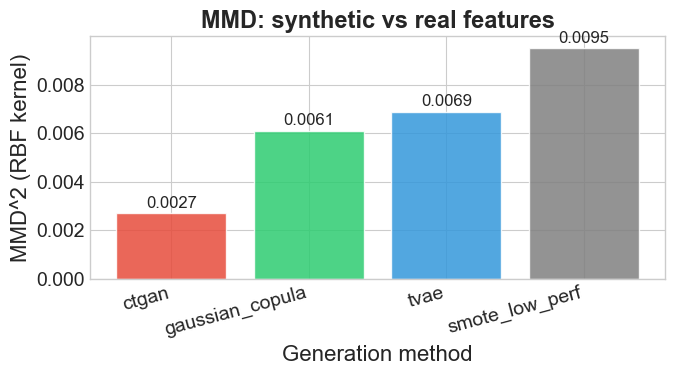

In [11]:
from src.utils.plotting import plot_mmd_bar


fig_mmd = plot_mmd_bar(metrics_df, cfg, save=True)
plt.show(); plt.close()

### 5.2 Utility

Absolute utility per (method, classifier); the real baseline is shown first. Balanced accuracy is the primary metric given the class imbalance.

2026-07-19 15:03:58 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\utility_balanced_accuracy.png


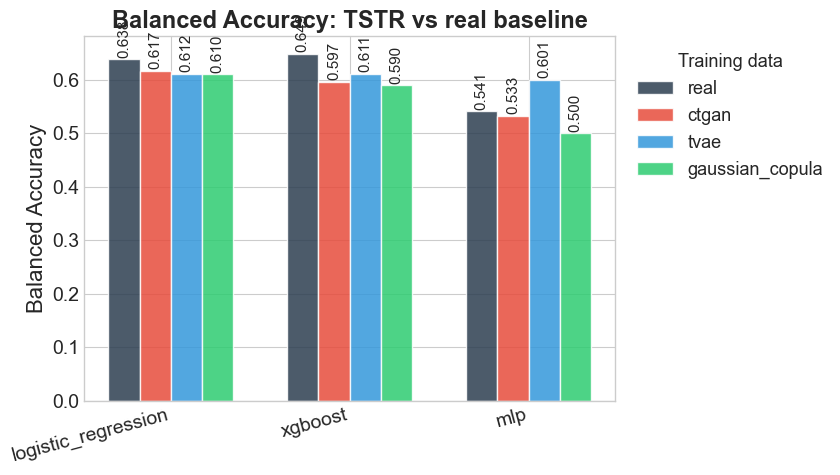

2026-07-19 15:03:59 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\utility_f1_macro.png


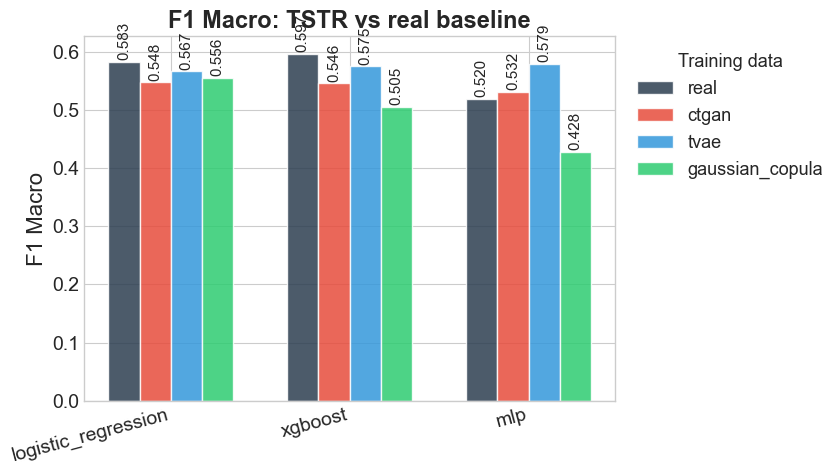

2026-07-19 15:03:59 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\utility_roc_auc.png


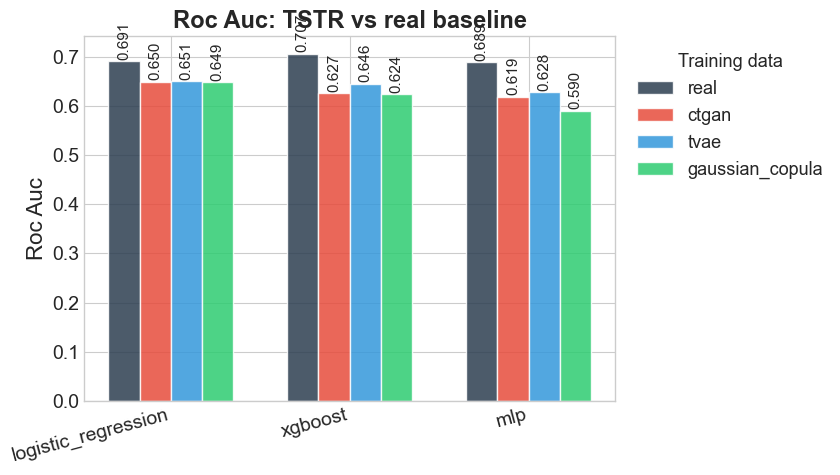

In [12]:
from src.utils.plotting import plot_utility_bar


utility_metric_cols = [
    m for m in cfg["experiments"]["utility_metrics"] if m != "mmd" and m in metrics_df.columns
]

for metric in utility_metric_cols:
    fig = plot_utility_bar(metrics_df, metric=metric, cfg=cfg, save=True)
    plt.show(); plt.close()

### 5.3 Fairness

Mean over the 8 available protected attributes. DPD and EOD: lower is fairer (0 = parity). DI: higher is fairer (below 0.8 fails the four-fifths rule).

2026-07-19 15:03:59 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\fairness_mean_dpd.png


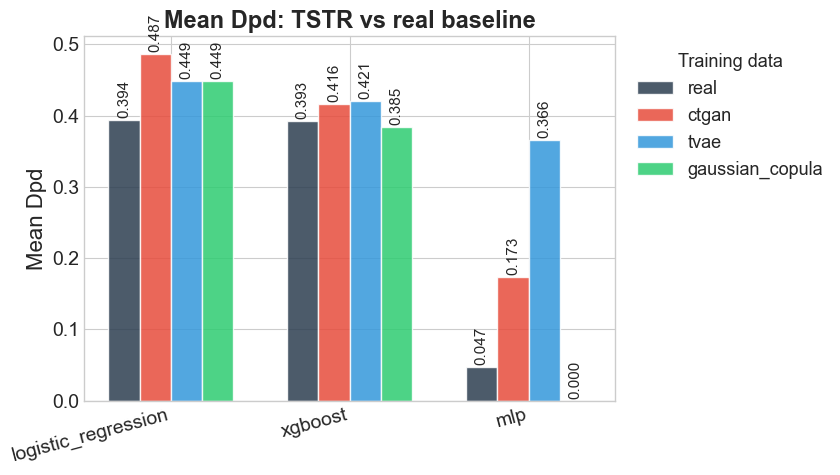

2026-07-19 15:04:00 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\fairness_mean_eod.png


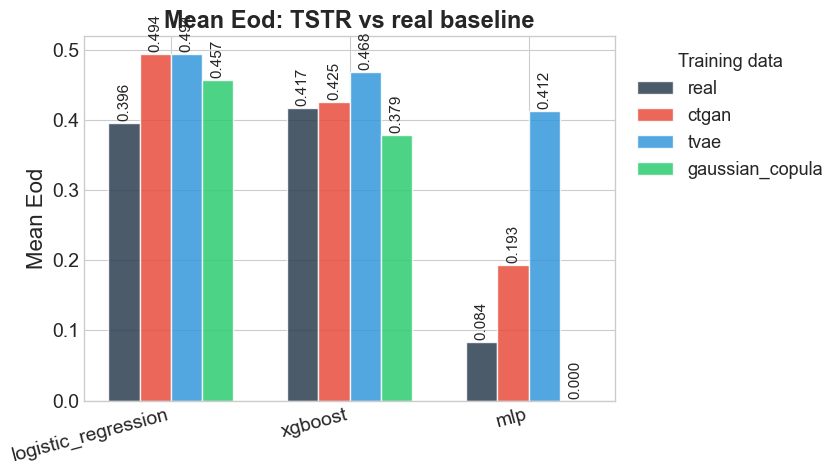

2026-07-19 15:04:00 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\fairness_mean_di.png


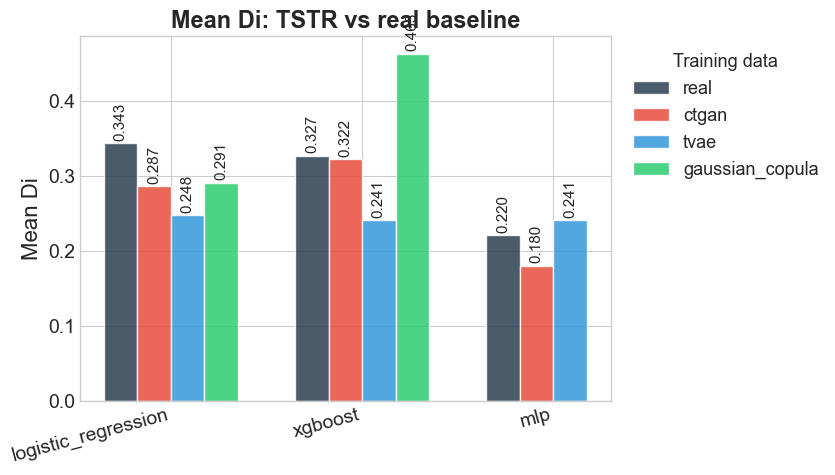

2026-07-19 15:04:00 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\fairness_mean_odds_ratio.png


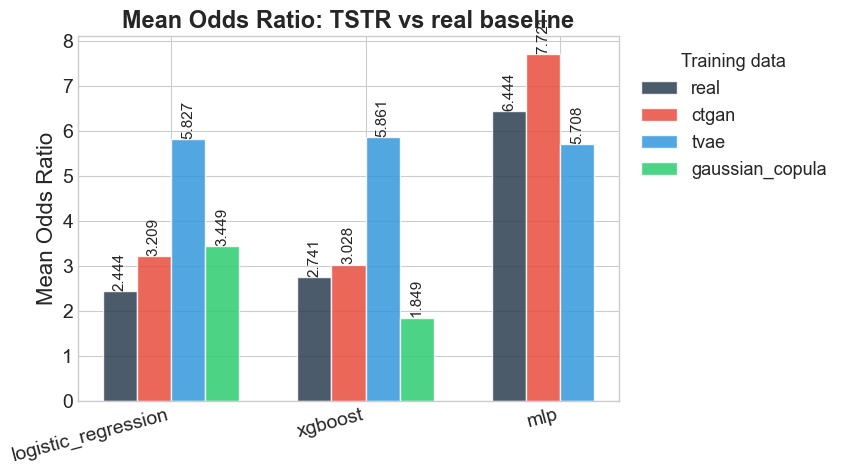

In [13]:
from src.utils.plotting import plot_fairness_bar


fairness_summary_cols = [c for c in metrics_df.columns if c.startswith("mean_")]

for metric in fairness_summary_cols:
    fig = plot_fairness_bar(metrics_df, metric=metric, cfg=cfg, save=True)
    plt.show(); plt.close()

### 5.4 Delta heatmaps

Change from the real baseline per classifier. Red = worse than real, blue = better.

2026-07-19 15:04:00 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\delta_heatmap_utility.png


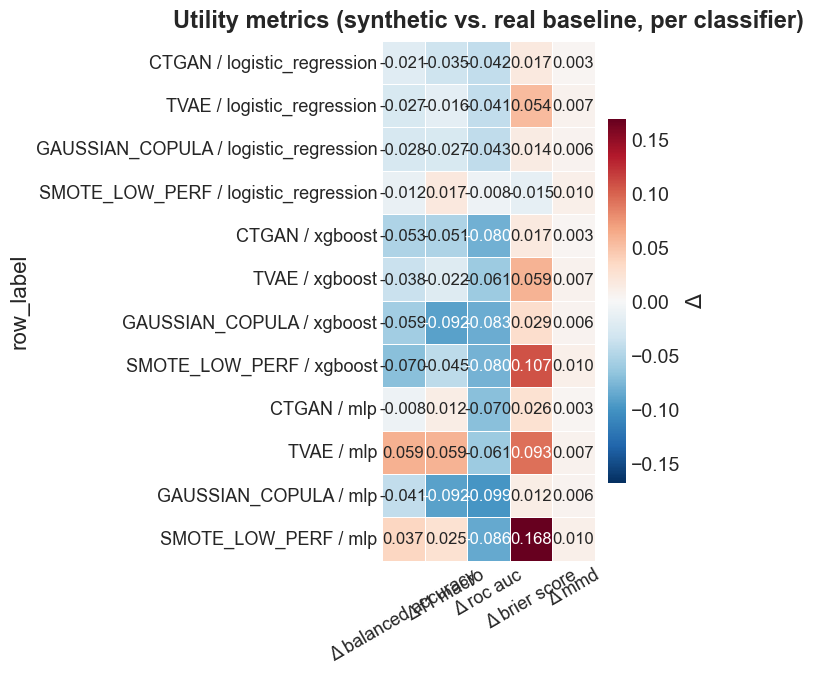

2026-07-19 15:04:01 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\delta_heatmap_fairness.png


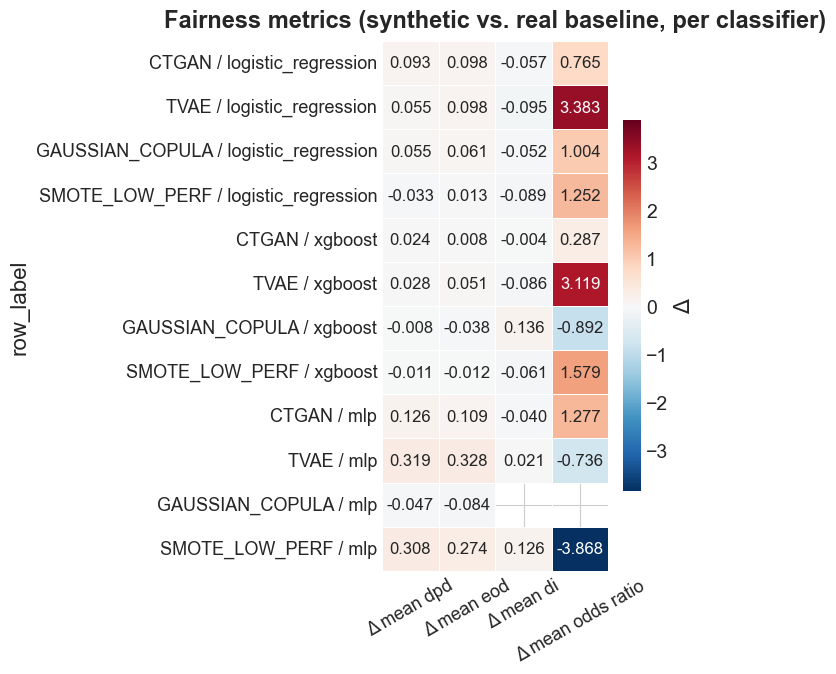

In [14]:
from src.utils.plotting import plot_delta_heatmap


# Utility delta heatmap
if util_delta_cols:
    fig = plot_delta_heatmap(
        delta_df,
        delta_columns=util_delta_cols,
        filename_suffix="utility",
        cfg=cfg,
        title="Utility metrics (synthetic vs. real baseline, per classifier)",
        save=True
    )
    plt.show(); plt.close()

# Fairness delta heatmap
if fair_delta_cols:
    fig = plot_delta_heatmap(
        delta_df,
        delta_columns=fair_delta_cols,
        filename_suffix="fairness",
        cfg=cfg,
        title="Fairness metrics (synthetic vs. real baseline, per classifier)",
        save=True
    )
    plt.show(); plt.close()

### 5.5 Utility loss vs fairness change

Does losing utility go together with losing fairness? Each point is a (method, classifier) pair on the balanced-accuracy-delta / mean-DPD-delta plane; the origin is the real baseline.

2026-07-19 15:04:01 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\scatter_utility_vs_fairness.png


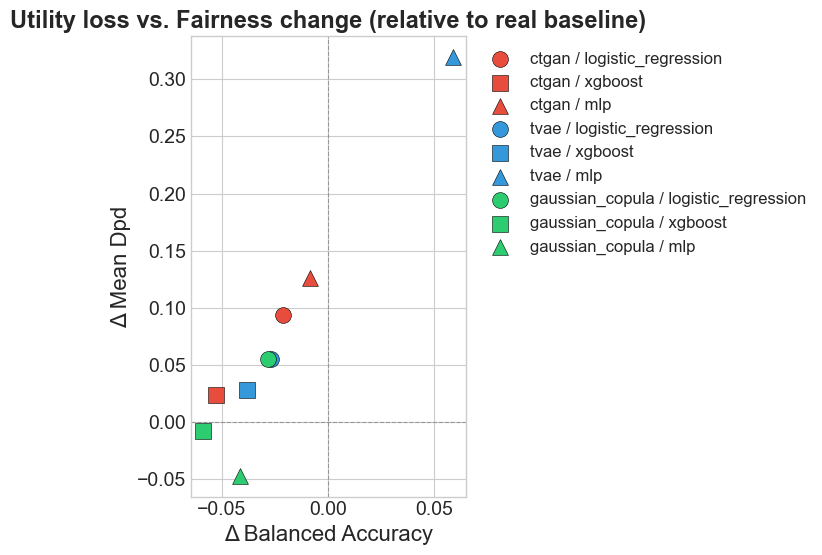

In [15]:
from src.utils.plotting import plot_utility_fairness_scatter


# Use balanced accuracy (primary utility metric) and mean DPD (primary fairness metric).
util_scatter_col = "delta_balanced_accuracy"
fair_scatter_col = "delta_mean_dpd"

if util_scatter_col in delta_df.columns and fair_scatter_col in delta_df.columns:
    fig = plot_utility_fairness_scatter(
        delta_df,
        utility_col=util_scatter_col,
        fairness_col=fair_scatter_col,
        cfg=cfg,
        save=True
    )
    plt.show(); plt.close()
else:
    logger.warning(
        f"Scatter requires '{util_scatter_col}' and '{fair_scatter_col}'. "
        "Check that balanced_accuracy and mean_dpd are in the metrics config."
    )

### 5.6 Per-attribute fairness

For each method we drill into the classifier with the worst mean DPD and show the three headline metrics (DPD, EOD, DI) per protected attribute, to see which circumstances (parental education, ESCS, ...) drive the aggregate numbers.

How to read: each bar is the size of the gap between the two groups of a circumstance. For DPD and EOD lower is fairer (green, left of the 0.1 line); for DI higher is fairer (green, right of the 0.8 four-fifths line). Gender stays near-fair across methods, while the socioeconomic circumstances (parental education, ESCS, books, occupation) drive the disparity.

2026-07-19 15:04:02 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_ctgan_logistic_regression.png


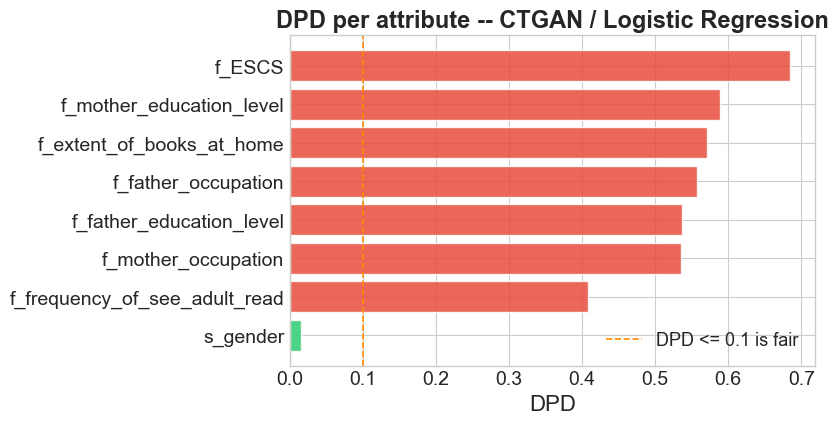

2026-07-19 15:04:02 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_ctgan_logistic_regression.png


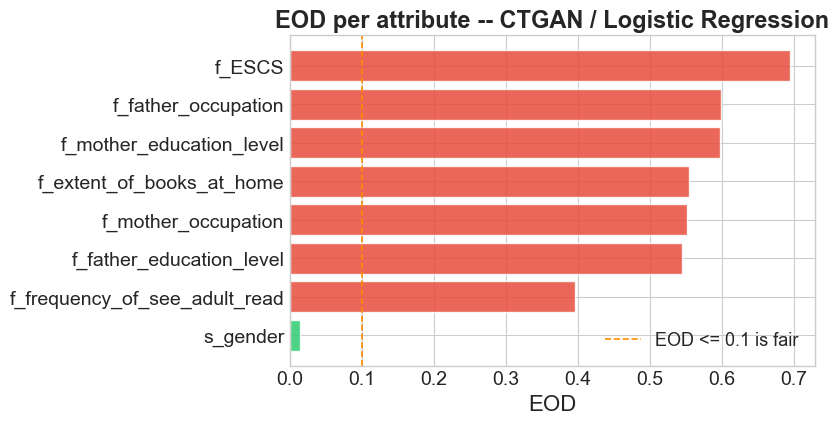

2026-07-19 15:04:02 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_ctgan_logistic_regression.png


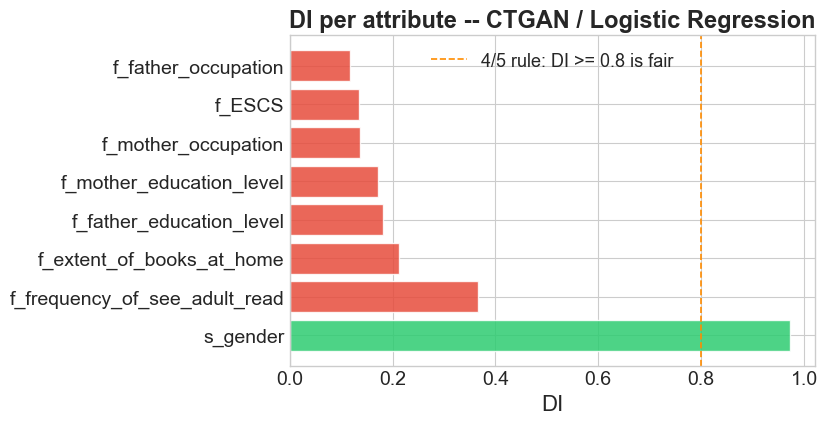

2026-07-19 15:04:02 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_tvae_logistic_regression.png


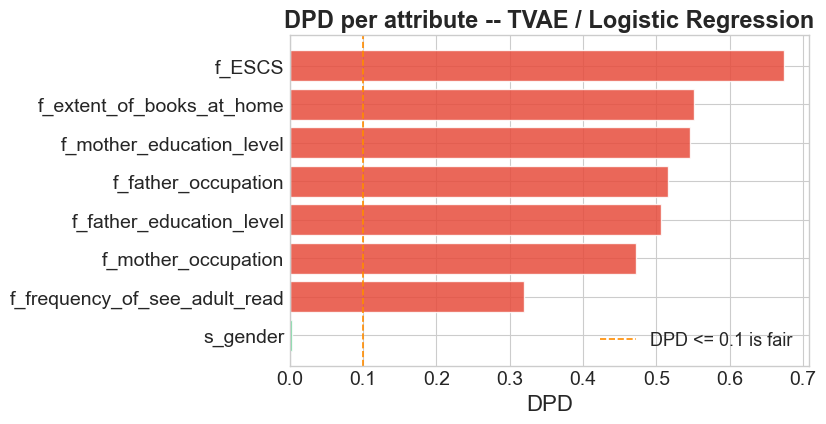

2026-07-19 15:04:03 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_tvae_logistic_regression.png


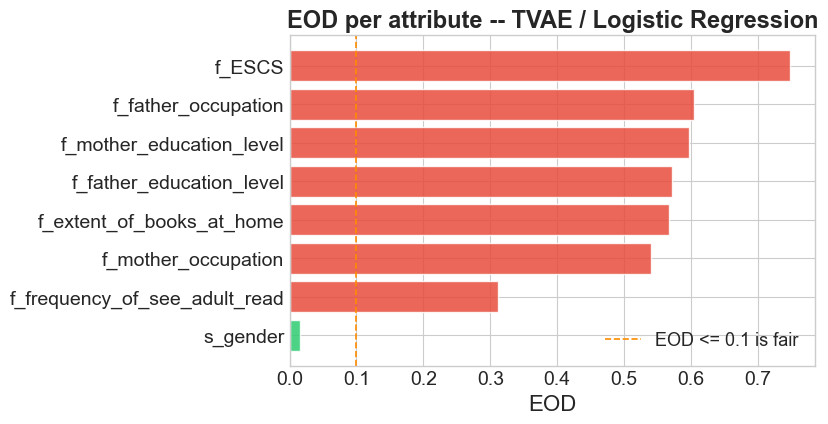

2026-07-19 15:04:03 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_tvae_logistic_regression.png


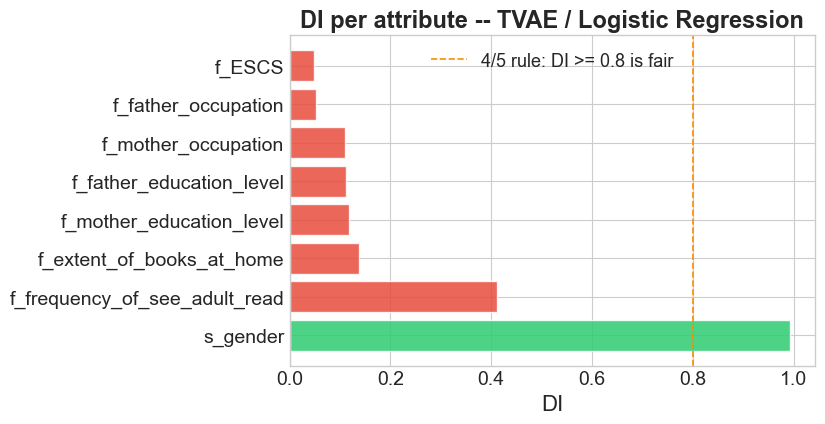

2026-07-19 15:04:03 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_gaussian_copula_logistic_regression.png


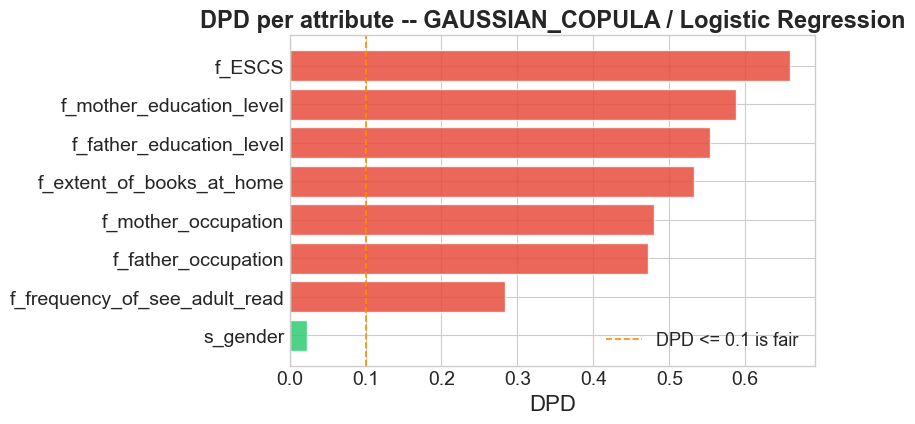

2026-07-19 15:04:03 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_gaussian_copula_logistic_regression.png


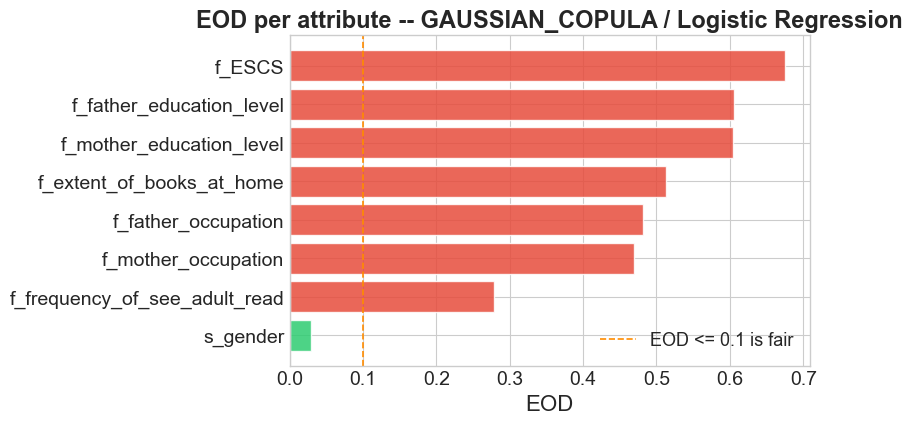

2026-07-19 15:04:04 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_gaussian_copula_logistic_regression.png


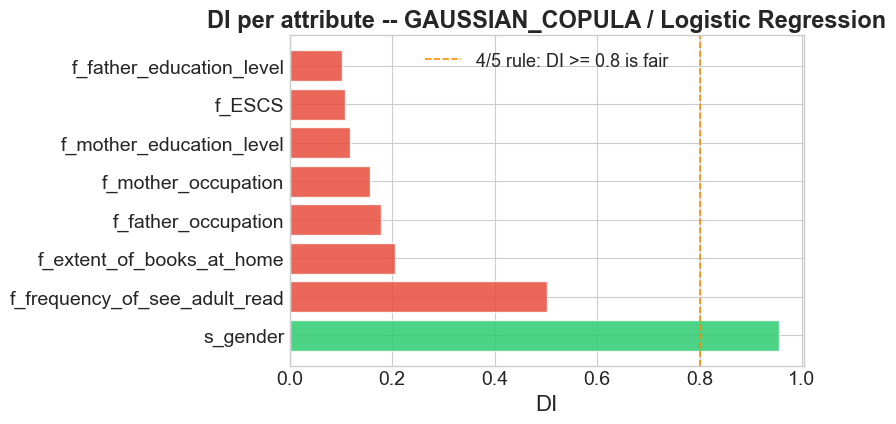

2026-07-19 15:04:04 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_dpd_smote_low_perf_xgboost.png


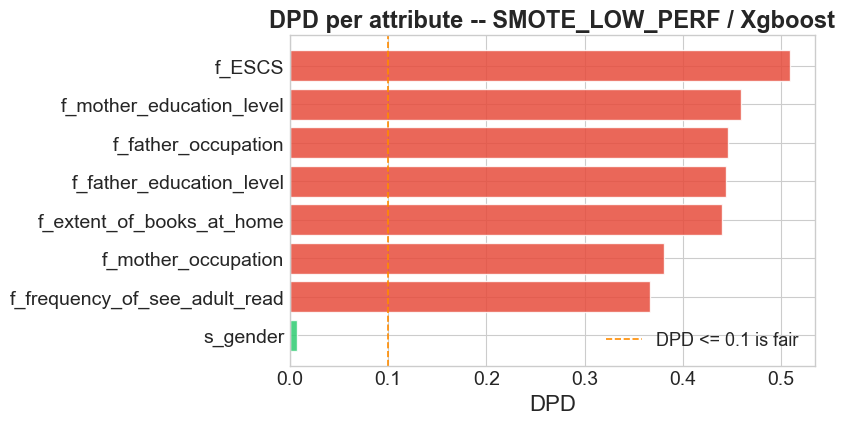

2026-07-19 15:04:04 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_eod_smote_low_perf_xgboost.png


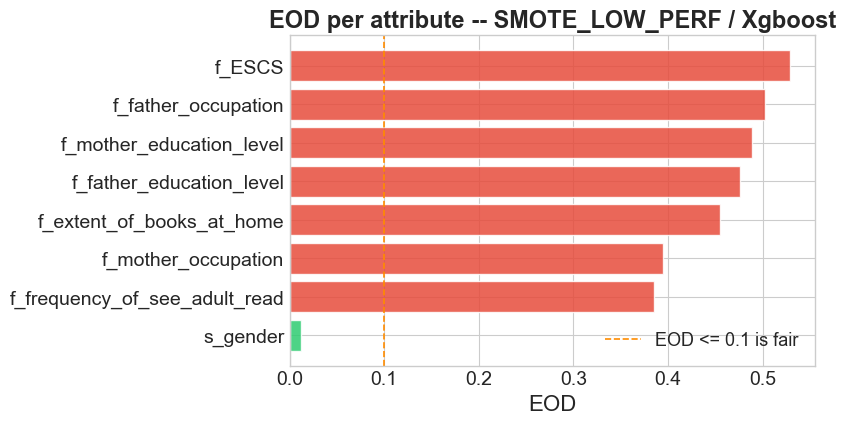

2026-07-19 15:04:04 | INFO     | src.utils.plotting | Figure saved -> D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\figures\low_perf\per_attr_di_smote_low_perf_xgboost.png


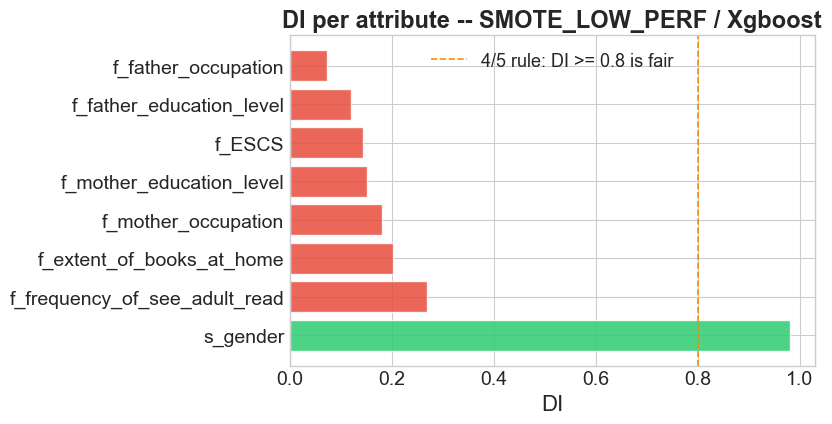

In [16]:
from src.utils.plotting import plot_per_attribute_fairness

# For each method, drill into the classifier with the worst mean DPD and show the
# three headline fairness metrics (DPD, EOD, DI) per protected attribute.
for method in METHODS:
    method_rows = metrics_df[metrics_df["method"] == method]
    worst_clf = method_rows.loc[method_rows["mean_dpd"].idxmax(), "classifier"]
    fair_df   = per_attr_fairness[method].get(worst_clf)

    for fairness_metric in ["dpd", "eod", "di"]:
        title = (
            f"{fairness_metric.upper()} per attribute -- "
            f"{method.upper()} / {worst_clf.replace('_', ' ').title()}"
        )
        fig = plot_per_attribute_fairness(
            fair_df,
            metric    = fairness_metric,
            cfg       = cfg,
            title     = title,
            save = True,
            filename_suffix = f"_{method}_{worst_clf}"
        )
        plt.show(); plt.close()

## 6. Summary tables

### 6.1 Utility by method

Utility averaged across classifiers, per method.

In [17]:
util_cols = [
    m for m in list(metrics_df.columns)
    if m not in ("method", "classifier", "mmd")
    and pd.api.types.is_numeric_dtype(metrics_df[m])
]

utility_summary = metrics_df.groupby("method")[util_cols].mean().round(4)

# Add MMD column (method-level, not classifier-level).
utility_summary["mmd"] = metrics_df.groupby("method")["mmd"].first().round(4)

display(utility_summary)

save_csv(utility_summary.reset_index(), EXPERIMENTS_DIR / "utility_summary.csv")

,balanced_accuracy,f1_macro,roc_auc,brier_score,mean_dpd,mean_eod,mean_di,mean_odds_ratio,s_gender_dpd,s_gender_eod,...,f_ESCS_eod,f_ESCS_di,f_ESCS_odds_ratio,repetition,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc,corr_mean_abs_delta,corr_max_abs_delta,mmd
method,,,,,,,,,,,,,,,,,,,,,
ctgan,0.5824,0.5420,0.6319,0.2248,0.3588,0.3709,0.2631,4.6526,0.0119,0.0163,...,0.5051,0.1299,6.3082,0.0,0.0272,0.0247,0.0639,0.0692,0.5513,0.0027
gaussian_copula,0.5669,0.4964,0.6211,0.2234,0.2778,0.2786,0.3767,2.6488,0.0090,0.0145,...,0.3935,0.2310,3.9731,0.0,0.0428,0.0703,0.0747,0.0716,0.7145,0.0061
real,0.6096,0.5667,0.6958,0.2048,0.2777,0.2991,0.2967,3.8766,0.0374,0.0356,...,0.4075,0.1449,5.8481,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
smote_low_perf,0.5945,0.5660,0.6379,0.2915,0.3658,0.3907,0.2887,3.5308,0.0288,0.0416,...,0.5054,0.1768,4.3242,0.0,0.0151,0.0007,0.0579,0.0189,0.6697,0.0095
tvae,0.6077,0.5738,0.6415,0.2731,0.4120,0.4583,0.2432,5.7985,0.0068,0.0160,...,0.6910,0.0454,15.0680,0.0,0.0019,-0.0072,0.0543,0.0516,0.4067,0.0069


2026-07-19 15:04:05 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\utility_summary.csv


### 6.2 Fairness by method

Mean fairness metrics averaged across classifiers, per method.

In [18]:
fairness_summary_cols = [c for c in metrics_df.columns if c.startswith("mean_")]

fairness_summary = metrics_df.groupby("method")[fairness_summary_cols].mean().round(4)

display(fairness_summary)

save_csv(fairness_summary.reset_index(), EXPERIMENTS_DIR / "fairness_summary.csv")

,mean_dpd,mean_eod,mean_di,mean_odds_ratio
method,,,,
ctgan,0.3588,0.3709,0.2631,4.6526
gaussian_copula,0.2778,0.2786,0.3767,2.6488
real,0.2777,0.2991,0.2967,3.8766
smote_low_perf,0.3658,0.3907,0.2887,3.5308
tvae,0.4120,0.4583,0.2432,5.7985


2026-07-19 15:04:05 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\fairness_summary.csv


### 6.3 Deltas by method

Mean change from the real baseline, per method. This is the headline table for the report.

In [19]:
delta_cols_all = util_delta_cols + fair_delta_cols

if delta_cols_all:
    delta_syn_subset = delta_df[
        (delta_df["method"] != baseline_label)
    ]
    delta_summary = delta_syn_subset.groupby("method")[delta_cols_all].mean().round(4)
    
    display(delta_summary)

    save_csv(delta_summary.reset_index(), EXPERIMENTS_DIR / "delta_summary.csv")

,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc,delta_brier_score,delta_mmd,delta_mean_dpd,delta_mean_eod,delta_mean_di,delta_mean_odds_ratio
method,,,,,,,,,
ctgan,-0.0272,-0.0247,-0.0639,0.0200,0.0027,0.0811,0.0718,-0.0336,0.7760
gaussian_copula,-0.0428,-0.0703,-0.0747,0.0185,0.0061,0.0001,-0.0205,0.0418,0.0559
smote_low_perf,-0.0151,-0.0007,-0.0579,0.0867,0.0095,0.0881,0.0916,-0.0080,-0.3458
tvae,-0.0019,0.0072,-0.0543,0.0683,0.0069,0.1343,0.1592,-0.0535,1.9219


2026-07-19 15:04:05 | INFO     | src.data.persistence | Saved CSV to D:\Users\Utente\OneDrive - Alma Mater Studiorum Università di Bologna\università\Studio\5ANNO\2SEMESTRE\Ethics\Project\Dev\petrellirambaldi2526\results\experiments\low_perf\delta_summary.csv


## 7. What we found

Saved artefacts mirror G4, under `results/experiments/low_perf/` and `results/figures/low_perf/`.

Key findings (underperformance task, target column: `target_low_perf`):

- On this task CTGAN essentially matches the real baseline on utility (mean balanced-accuracy delta ~0.00, ROC-AUC -0.02) and is the most faithful method; Gaussian Copula and SMOTE(low) lose a little more, TVAE the most on AUC.
- Positive-rate distortion is smaller here: CTGAN 38% and Gaussian Copula 25% vs the real 25%, while TVAE again collapses to 9% and SMOTE(low) is forced to 50%.
- Fairness moves the opposite way from the excellence task. DPD does not fall for CTGAN or SMOTE, it rises (CTGAN 0.35, SMOTE 0.37 vs 0.28 real). Only TVAE shows the familiar collapse-driven drop (DPD 0.12) together with the largest AUC loss.
- So the "synthetic looks fairer" effect seen in G4 is not a general property: it appears only when the generator collapses the positive class, and which class that is depends on the task. When class balance is roughly preserved (CTGAN, Copula), fairness tracks the real baseline or worsens slightly.
- mean_odds_ratio is unstable on this task (values of 2-6, with NaNs when a group has no positives), so we rely on DPD, EOD and DI.